In [2]:
from scipy.io import loadmat
from numpy import asarray
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numpy.matlib
from scipy import signal
from scipy.signal import welch
from scipy.stats import entropy
from scipy.fft import fft, fftfreq
import os
import glob
from warnings import warn
from sklearn import metrics
plt.rc('font',family='Times New Roman')
import warnings 
warnings.filterwarnings('ignore')

In [3]:
def apply_fft(x, fs):
    N = len(x)
    T = 1.0 / fs
    fft_coef = fft(x-np.mean(x))
    xf = fftfreq(N, T)[:N//2] 
    fft_positve = 2.0/N * np.abs(fft_coef[0:N//2])
    return xf, fft_positve

In [4]:
def make_dataset(data_src):
    files = glob.glob(data_src)
    dataset_df = []
    for file in files:
        dataset_df.append(pd.read_csv(file, header = None))
    dataset = pd.concat(dataset_df, ignore_index=True, axis= 1)
    return dataset.T

In [5]:
def compute_psd(signal, length, fs):
    seg_length =  length/2 
    overlap = seg_length/3 
    nfft_length = 1024 
    frequencies, psd = welch(signal,  fs = fs, window='hann', nperseg= seg_length, noverlap= overlap, nfft= nfft_length)
    
    return frequencies, psd

In [6]:
def spectral_features(signal, fs):
    L = len(signal)
    frequencies, psd = compute_psd(signal, L,  fs)
    psd_norm = psd / np.sum(psd)
    spectral_centroid = np.sum(frequencies * psd_norm)
    spectral_spread = np.sqrt(np.sum(((frequencies - spectral_centroid) ** 2) * psd_norm))
    spectral_entropy = entropy(psd)
    peak_freq = frequencies[np.argmax(psd)] # peak freq.
    peak_pwr = np.max(psd)
    return spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr

In [7]:
data_path = r'../data/'
A  = make_dataset(os.path.join(data_path,  'A/*'))
B  = make_dataset(os.path.join(data_path,  'B/*'))
C  = make_dataset(os.path.join(data_path,  'C/*'))
D  = make_dataset(os.path.join(data_path,  'D/*'))
E  = make_dataset(os.path.join(data_path,  'E/*'))

In [8]:
normal = pd.concat([A, B]).reset_index(drop=True).to_numpy()
interictal = pd.concat([C, D]).reset_index(drop=True).to_numpy()
ictal = E.to_numpy()

In [9]:
num_samples =500
fs =  173.61

In [10]:
data = normal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
normal = np.array(slices).reshape(int(num_segments), num_samples)
data = interictal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
interictal = np.array(slices).reshape(int(num_segments), num_samples)
data = ictal.reshape(-1)
num_segments = np.floor(len(data)/num_samples)
slices = np.split(data[0:int(num_segments*num_samples)], num_samples)
ictal = np.array(slices).reshape(int(num_segments), num_samples)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

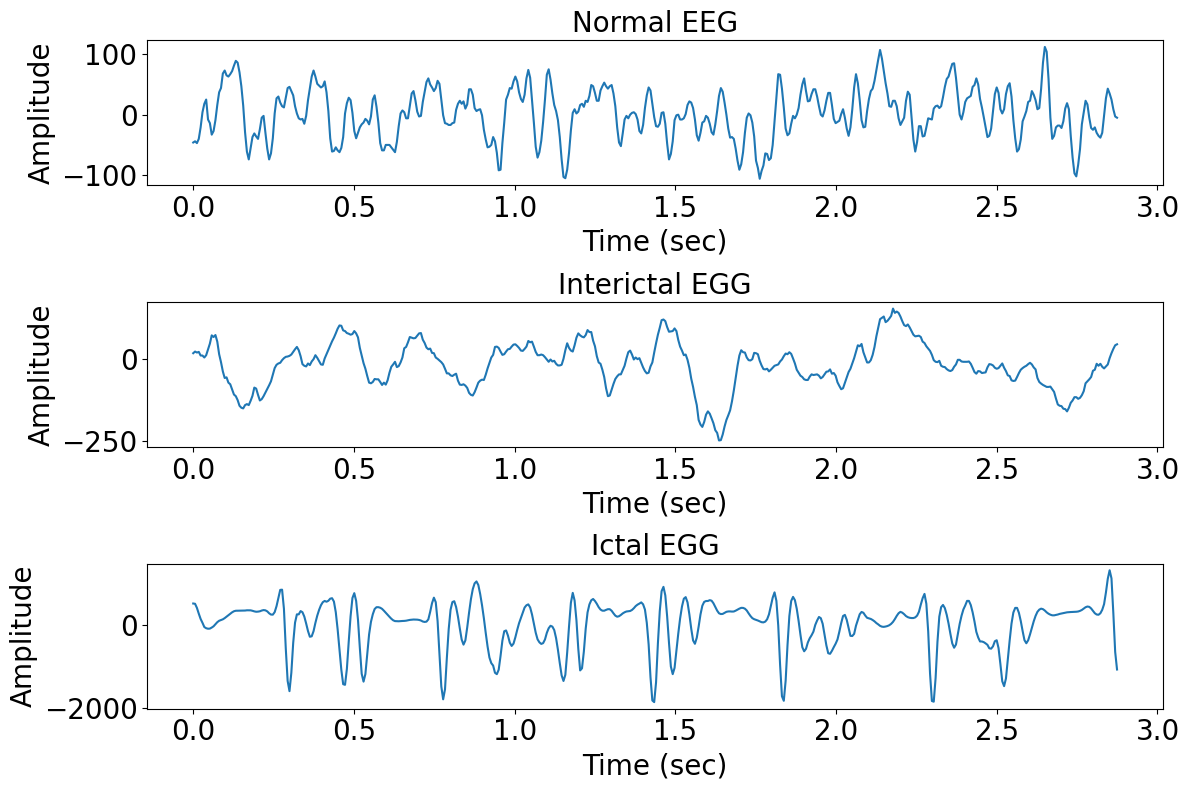

In [11]:
index = 0
normal_EEG = normal[index]
interictal_EGG = interictal[index]
ictal_EGG = ictal[index]
time = np.arange(0.0, len(normal_EEG), 1.0)/fs
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, normal_EEG)
plt.xlabel('Time (sec)', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Normal EEG", fontsize = 20)
plt.subplot(3, 1, 2)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, interictal_EGG)
plt.xlabel('Time (sec)', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Interictal EGG", fontsize = 20)
plt.subplot(3, 1, 3)
plt.tick_params('x', labelsize=20)
plt.tick_params('y', labelsize=20)
plt.plot(time, ictal_EGG)
plt.xlabel('Time (sec)', fontsize =20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title("Ictal EGG", fontsize = 20)
plt.tight_layout()
plt.show()

In [12]:
normal_labels = np.zeros(len(normal))
interictal_labels = np.ones(len(interictal))
ictal_labels = np.ones(len(ictal))*2
X = np.concatenate( (normal, interictal, ictal) , axis=0, out=None)
Y = np.concatenate( (normal_labels, interictal_labels, ictal_labels ) , axis=0, out=None)
print("data set features size:", X.shape)
print("data set labels size:", Y.shape)
print(X.shape)

data set features size: (4095, 500)
data set labels size: (4095,)
(4095, 500)


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


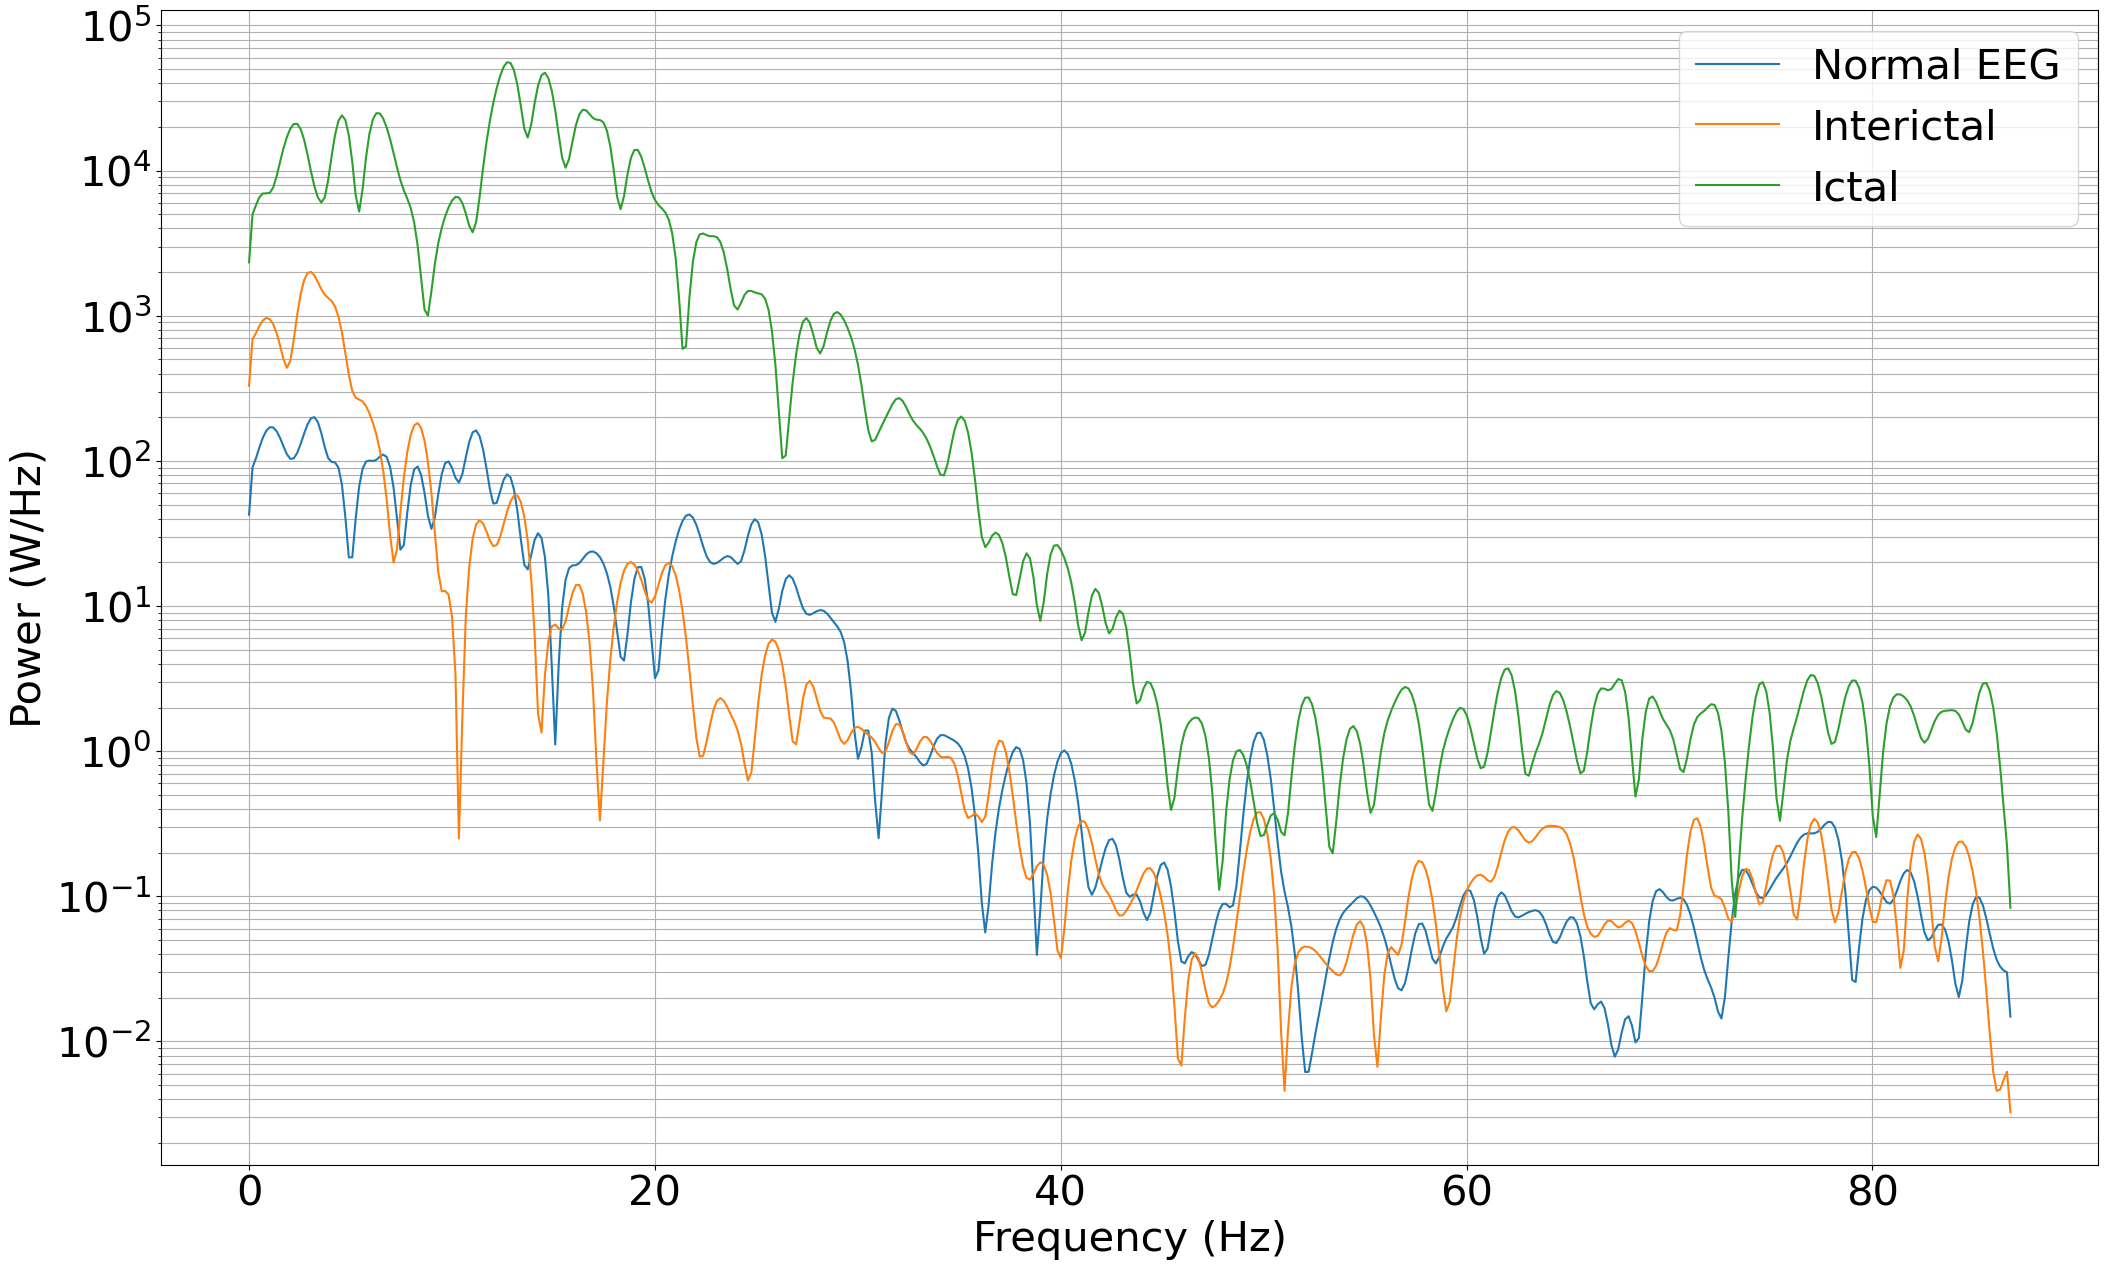

In [13]:
f1, psd1 = compute_psd(normal[index], len(normal[index]),  fs)
f2, psd2 = compute_psd(interictal[index],len(interictal[index]),   fs)
f3, psd3 = compute_psd(ictal[index],len(interictal[index]),   fs)
plt.figure(figsize=(25, 15))
plt.grid(True, which ="both")
plt.semilogy(f1, psd1, label = 'Normal EEG')
plt.semilogy(f2, psd2, label = 'Interictal')
plt.semilogy(f3, psd3, label = 'Ictal')
plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Power (W/Hz)', fontsize = 30)
plt.tick_params(axis='both', which='major', labelsize=30)
plt.tick_params(axis='both', which='minor', labelsize= 30)
plt.legend(fontsize=30)
plt.show()

In [14]:
from scipy.signal import butter, filtfilt
N = 4
b, a = butter(N, [0.5, 30],fs =fs,  btype='band', analog=False)

In [15]:
signal = X[0]
filtered_signal = filtfilt(b, a, signal)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

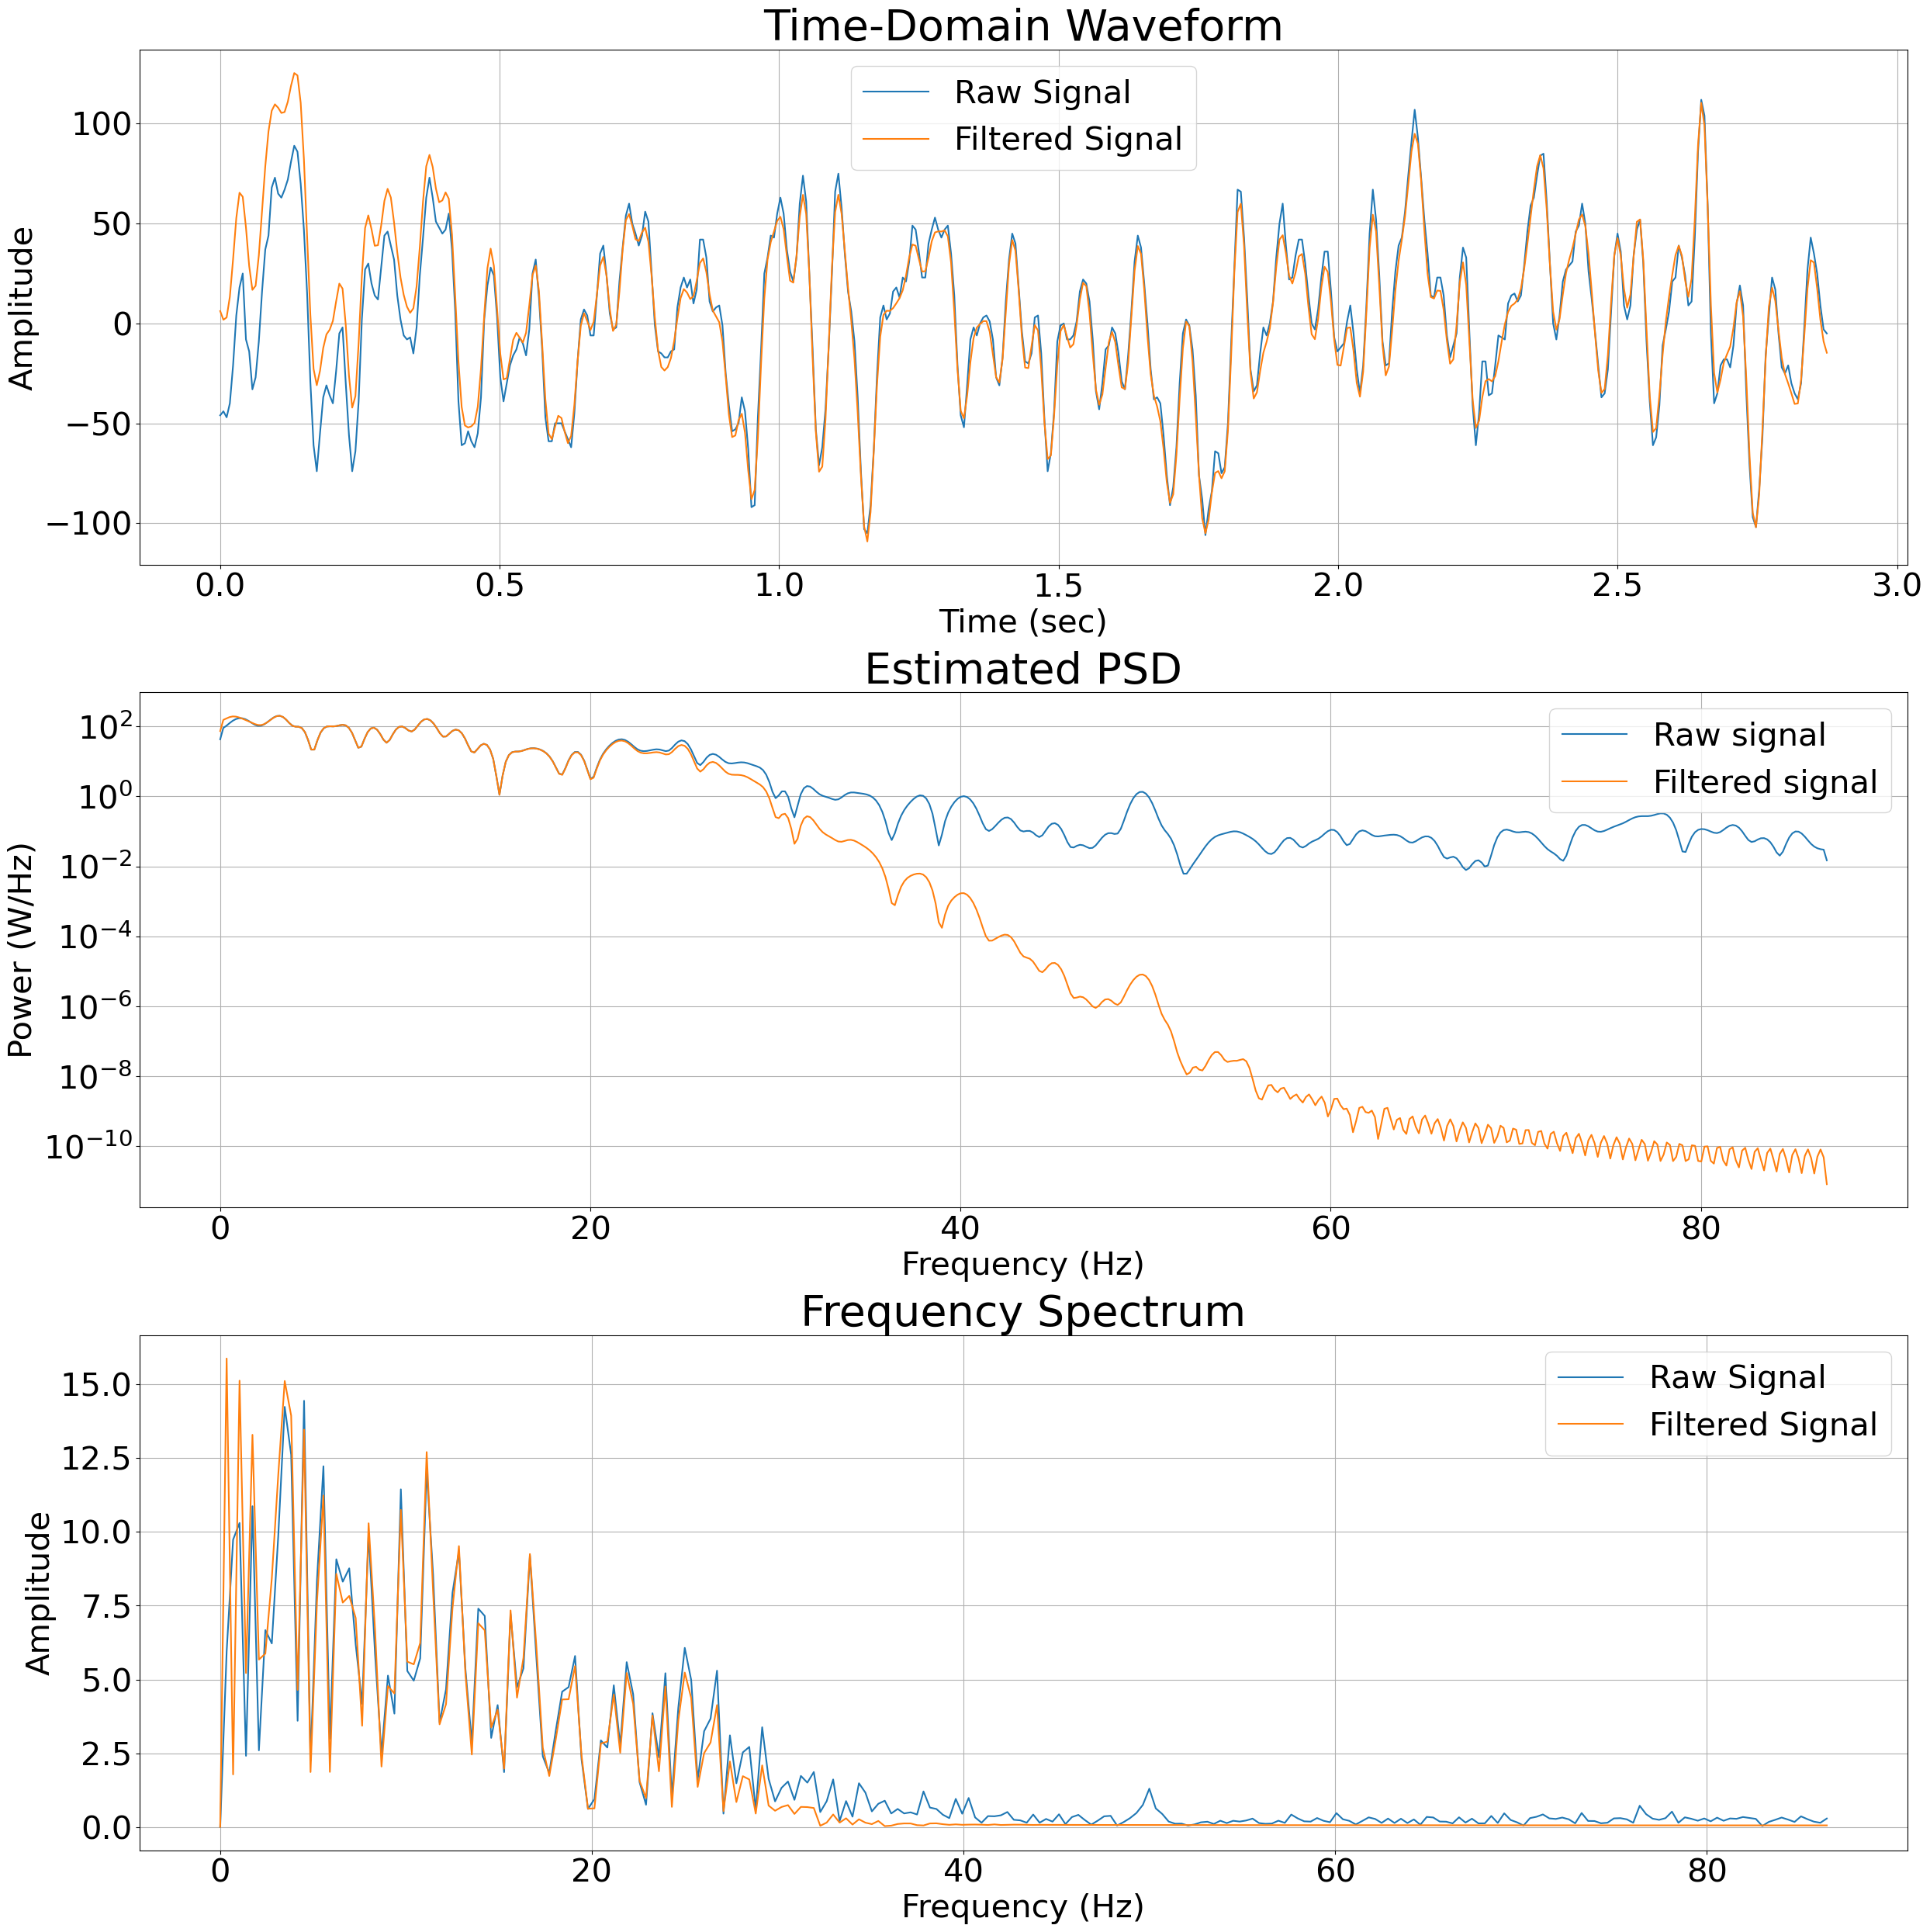

In [16]:
time = np.arange(0.0, len(signal), 1.0)/fs

f1, psd1 = compute_psd(signal, len(signal), fs)
f2, psd2 = compute_psd(filtered_signal,len(filtered_signal),  fs)

f_raw, x_raw = apply_fft(signal, fs)
f_lp, x_lp = apply_fft(filtered_signal, fs)

plt.figure(figsize=(25, 25))
plt.subplot(3, 1, 1)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.plot(time, signal, label='Raw Signal')
plt.plot(time, filtered_signal, label='Filtered Signal')
plt.xlabel('Time (sec)', fontsize = 30)
plt.ylabel('Amplitude', fontsize = 30)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.title('Time-Domain Waveform', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)
plt.subplot(3, 1, 2)
plt.semilogy(f1, psd1, label = 'Raw signal')
plt.semilogy(f2, psd2, label = 'Filtered signal')
plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Power (W/Hz)', fontsize = 30)
plt.tick_params(axis='both', which='major', labelsize=30)
plt.tick_params(axis='both', which='minor', labelsize= 30)
plt.title('Estimated PSD', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)
plt.subplot(3, 1, 3)
plt.plot(f_raw, x_raw, label='Raw Signal')
plt.plot(f_lp, x_lp, label='Filtered Signal')
plt.xlabel('Frequency (Hz)', fontsize = 30)
plt.ylabel('Amplitude', fontsize = 30)
plt.tick_params('x', labelsize=30)
plt.tick_params('y', labelsize=30)
plt.title('Frequency Spectrum', fontsize = 40)
plt.legend(fontsize=30)
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
num_signals = len(X)
num_features = 5
feature_matrix = np.zeros((num_signals, num_features))
for i in range(num_signals):
    sig_in = filtfilt(b, a, X[i])
    spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr = spectral_features(sig_in, fs)
    feature_matrix[i, :] = [spectral_centroid, spectral_spread, spectral_entropy, peak_freq, peak_pwr]
feature_matrix

array([[7.97523287e+00, 6.69675112e+00, 4.70893124e+00, 3.22127930e+00,
        1.99937893e+02],
       [9.97926495e+00, 6.23170995e+00, 4.72583090e+00, 7.29026367e+00,
        2.25206731e+02],
       [8.29025335e+00, 6.59312967e+00, 4.58749841e+00, 1.35632813e+00,
        4.61976291e+02],
       ...,
       [6.31754239e+00, 5.12048642e+00, 4.53758052e+00, 6.78164063e-01,
        6.53619898e+03],
       [6.58476229e+00, 4.72625398e+00, 4.46509483e+00, 2.20403320e+00,
        5.71308127e+03],
       [6.96291032e+00, 5.07327657e+00, 4.51370666e+00, 1.52586914e+00,
        5.54553569e+03]])

In [18]:
print(feature_matrix.shape)

(4095, 5)


In [19]:
!pip install scikit-optimize


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [20]:
from skopt import Optimizer
from skopt import BayesSearchCV 
from skopt.space import Real, Categorical, Integer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score, confusion_matrix

In [21]:
labels = Y

In [22]:
X_train, X_test, y_train, y_test = train_test_split(feature_matrix, labels, test_size = 0.2,shuffle = True, stratify = labels, random_state = 42)

In [23]:
X_train.shape

(3276, 5)

In [24]:
X_test.shape

(819, 5)

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_data_scaled = scaler.fit_transform(X_train)
test_data_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report
import numpy as np
from tqdm import tqdm
import time

# Random Forest hyperparameter search
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

print("Training Random Forest...")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=5,
    cv=3,
    scoring='accuracy',
    random_state=42
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best Random Forest:", best_rf)

# SVC hyperparameter search with progress bar
svc_param_dist = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'probability': [True]
}

print("\nTraining SVC with progress tracking...")

# SVC hyperparameter search with manual progress tracking
print("SVC hyperparameter combinations to test: 5")
print("Progress: ", end="", flush=True)

svc_search = RandomizedSearchCV(
    SVC(),
    svc_param_dist,
    n_iter=5,  # Reduced from 10 to 5
    cv=3,
    scoring='accuracy',
    random_state=42,
    verbose=1  # This will show some progress info from sklearn
)

# Manual progress simulation
with tqdm(total=5, desc="SVC Search", unit="combination") as pbar:
    # Fit the search
    svc_search.fit(X_train, y_train)
    pbar.update(5)  # Complete the progress bar
best_svc = svc_search.best_estimator_
print("Best SVC:", best_svc)

# Stacking Classifier
print("\nTraining Stacking Classifier...")
final_estimator = LogisticRegressionCV(multi_class='auto', max_iter=10, cv=5)

stacking_clf = StackingClassifier(
    estimators=[('rf', best_rf), ('svc', best_svc)],
    final_estimator=final_estimator,
    cv=5
)

# Add progress indication for stacking
print("Fitting base estimators and final estimator...")
stacking_clf.fit(X_train, y_train)

print("Making predictions...")
y_pred = stacking_clf.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Training Random Forest...
Best Random Forest: RandomForestClassifier(min_samples_split=10, n_estimators=300, random_state=42)

Training SVC with progress tracking...
SVC hyperparameter combinations to test: 5
Progress: 

SVC Search:   0%|                                                                        | 0/5 [00:00<?, ?combination/s]

Fitting 3 folds for each of 5 candidates, totalling 15 fits
